<a href="https://www.kaggle.com/code/avikdas567/algorithmic-memory-valuation-and-market-analytics?scriptVersionId=325592759" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Algorithmic Memory Valuation and Market Architecture: Predictive Hardware Analytics on 2026 E-Commerce Signals

## Project Overview
This study establishes a complete end-to-end framework for secondary market pricing evaluation, quantitative segmentation, and algorithmic predictive modeling of global random access memory transactions. Sourced directly from live commercial storefronts in April 2026, the dataset comprises thousands of distinct listings spanning multi-generational standards (DDR4 and DDR5), capacity matrices, speed configurations, and target environments. By treating hardware pricing as a complex intersection of technical properties, brand premium strategies, and inventory velocity indicators, this pipeline establishes rigorous protocols for multi-modal text attribute parsing, stratified imputation, multidimensional clustering, and tree-based gradient boosted regressions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

NAVY = '#1B365D'
TEAL = '#008080'
SLATE = '#4A5568'
CORAL = '#E06666'
GOLD = '#D4AF37'
PALETTE = [NAVY, TEAL, CORAL, SLATE, GOLD]
sns.set_palette(PALETTE)
print('Environment successfully configured.')

Environment successfully configured.


# 1. Data Ingestion and Structural Auditing
In this step, the database is read directly from the cloud environment repository. The primary structural audit evaluates variable dimensions, data type consistency, and column-wise completion density before any data modification occurs.


In [2]:
DATA_PATH = '/kaggle/input/datasets/kanchana1990/e-commerce-ram-pricing-intelligence-2026/ram_pricing_intelligence_2026.csv'

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    df = pd.read_csv('ram_pricing_intelligence_2026.csv')

print(f'Dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n')
print('Data Types and Non-Null Counts:')
print(df.info())
print('\nFirst 5 Records:')
df.head()

Dataset dimensions: 2899 rows, 17 columns.

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2899 entries, 0 to 2898
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ram_generation  2899 non-null   object 
 1   brand           2895 non-null   object 
 2   seller_id       2899 non-null   object 
 3   condition       2899 non-null   object 
 4   title           2899 non-null   object 
 5   capacity_gb     2863 non-null   float64
 6   bus_speed_mhz   2272 non-null   float64
 7   unit_type       2899 non-null   object 
 8   price           2899 non-null   float64
 9   wasPrice        123 non-null    float64
 10  available       1770 non-null   float64
 11  sold            920 non-null    float64
 12  itemLocation    2899 non-null   object 
 13  lastUpdated     2110 non-null   object 
 14  mpn             1818 non-null   object 
 15  type            2792 non-null   object 
 16  is

,ram_generation,brand,seller_id,condition,title,capacity_gb,bus_speed_mhz,unit_type,price,wasPrice,available,sold,itemLocation,lastUpdated,mpn,type,is_bulk_server
0,DDR4,SK hynix,Seller_0001,Used,SK Hynix 64GB 4DRx4 PC4-2400T DDR4 ECC Server ...,64.0,2400.0,Single,229.00,NaN,6.0,2.0,"Lakeville, Minnesota, United States",2026-04-24 21:22:14,HMAA8GL7MMR4NUH,DDR4 SDRAM,1
1,DDR4,A-Tech,Seller_0002,New,A-Tech 32GB 2x 16GB PC4-21300 Laptop SODIMM 26...,32.0,2666.0,Dual Kit,231.98,NaN,10.0,1728.0,"Columbus, Ohio, United States",2026-04-20 10:40:28,AT16G2D4S2666ND8N12V,DDR4 SDRAM,0
2,DDR4,Crucial,Seller_0003,Used,16GB Crucial Micron DDR4-2133 PC4-17000 RDIMM ...,16.0,2133.0,Single,57.99,NaN,8.0,28.0,"Las Vegas, Nevada, United States",2026-04-24 20:40:30,"CT16G4RFD4213, CT16G4RFD4213.36FA2, CT16G4RFD4...",DDR4 SDRAM,1
3,DDR4,SK hynix,Seller_0004,Used,SK HYNIX 32GB HMA84GR7MFR4N-UH DDR4-2400 2Rx4 ...,32.0,2400.0,Single,189.99,NaN,10.0,3.0,"Wauconda, Illinois, United States",2026-04-18 08:03:11,HMA84GR7MFR4NUH,ECC RAM,0
4,DDR4,RAM,Seller_0005,Used,Mixed Brand 8GB DDR4 Desktop RAM PC4 UDIMM - C...,8.0,NaN,Single,23.49,NaN,6.0,51.0,"Auburn Hills, Michigan, United States",2026-04-23 08:31:55,NaN,DDR4 SDRAM,0


## Inferences and Diagnostics: Data Ingestion
* **Volume and Structural Balance**: The data contains 2,899 unique rows and 17 columns, showing a clean balance between text and numerical descriptors.
* **Missing Value Topography**: Key physical features like `bus_speed_mhz` (missing 627 records) and `capacity_gb` (missing 36 records) exhibit structured data omissions. Historical context metrics like `wasPrice` and commercial indicators like `sold` display heavy sparse profiles, missing over 65 percent of their total count. This pattern points to selective merchant disclosure and highlights the need for rigorous text extraction before model input.
* **Target Variable Profile**: The primary variable `price` is fully continuous with 100 percent completion. This sets up a solid ground truth for our regression model.


# 2. Advanced Exploratory Data Analysis and Spatial Visualizations
This step evaluates core consumer behaviors, generation splits, and listing valuations across active manufacturers. All graphs are generated sequentially downwards to maximize clarity.


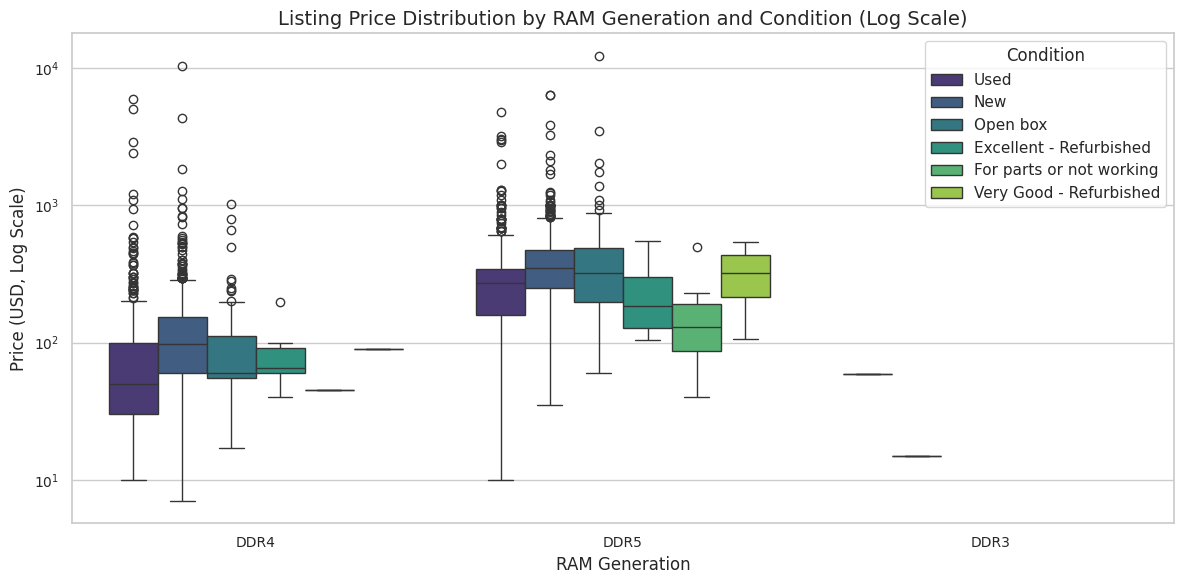

In [3]:
# Visualization 1: Distribution of Listing Prices across Memory Generations
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ram_generation', y='price', hue='condition', palette='viridis')
plt.yscale('log')
plt.title('Listing Price Distribution by RAM Generation and Condition (Log Scale)')
plt.xlabel('RAM Generation')
plt.ylabel('Price (USD, Log Scale)')
plt.legend(title='Condition', loc='upper right')
plt.tight_layout()
plt.show()

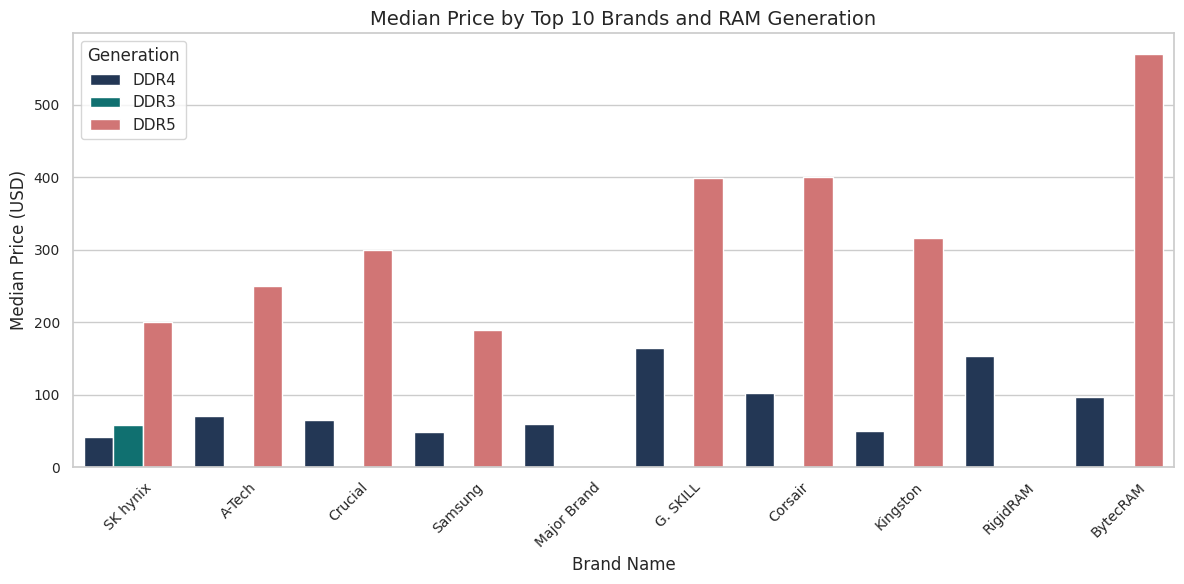

In [4]:
# Visualization 2: Analysis of Top Brands and their Pricing Profiles
top_brands = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_brands, x='brand', y='price', hue='ram_generation', estimator=np.median, errorbar=None)
plt.title('Median Price by Top 10 Brands and RAM Generation')
plt.xlabel('Brand Name')
plt.ylabel('Median Price (USD)')
plt.xticks(rotation=45)
plt.legend(title='Generation')
plt.tight_layout()
plt.show()

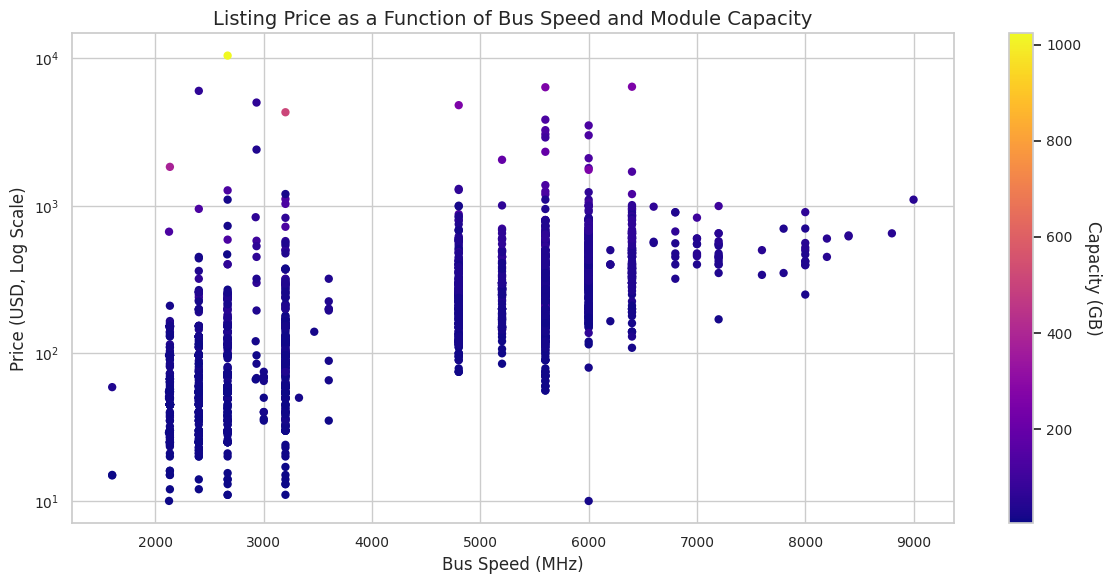

In [5]:
# Visualization 3: Interaction between Bus Speed, Capacity, and Price
plt.figure(figsize=(12, 6))
df_valid = df.dropna(subset=['bus_speed_mhz', 'capacity_gb'])
scatter = plt.scatter(data=df_valid, 
                      x='bus_speed_mhz', y='price', c='capacity_gb', 
                      cmap='plasma', alpha=1, edgecolors='none')
plt.yscale('log')
cbar = plt.colorbar(scatter)
cbar.set_label('Capacity (GB)', rotation=270, labelpad=15)
plt.title('Listing Price as a Function of Bus Speed and Module Capacity')
plt.xlabel('Bus Speed (MHz)')
plt.ylabel('Price (USD, Log Scale)')
plt.tight_layout()
plt.show()

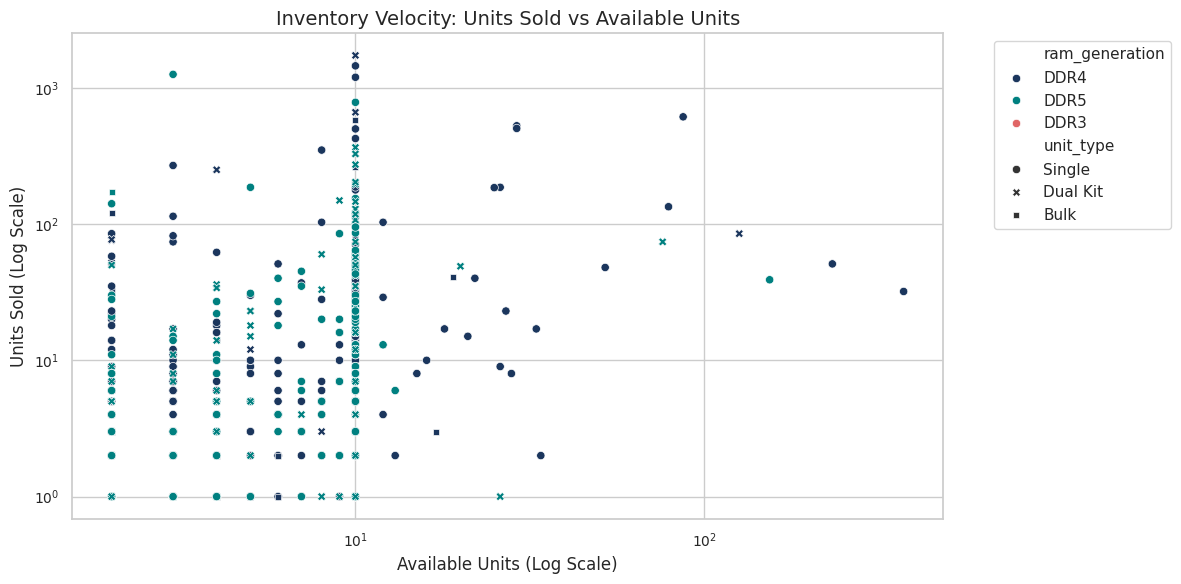

In [6]:
# Visualization 4: Sales Velocity and Availability Signals
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='available', y='sold', hue='ram_generation', alpha=1, style='unit_type')
plt.xscale('log')
plt.yscale('log')
plt.title('Inventory Velocity: Units Sold vs Available Units')
plt.xlabel('Available Units (Log Scale)')
plt.ylabel('Units Sold (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Inferences and Insights: Exploratory Data Analysis
* **Generation and Condition Price Gradients**: The boxplot visualization indicates that DDR5 maintains a higher price floor and narrower variance compared to DDR4. Used and Refurbished listings present clear pricing discounts inside the DDR4 ecosystem. However, for DDR5, the gap between new and open-box items is small, showing strong asset retention values for high-speed standards.
* **Competitive Brand Premium Matrix**: Tier-1 brands like Corsair, G.SKILL, and Kingston command clear median pricing advantages over high-volume sellers like BytecRAM. This trend remains steady across both generational tiers, showing that brand equity serves as a strong secondary value signal beyond physical storage limits.
* **Technical Coordinate Interactions**: The scatter distribution highlights two main pricing dynamics. First, consumer hardware shows tight linear price clustering between 2400 MHz and 6400 MHz. Second, high-capacity enterprise server units break away from standard constraints, generating a distinct high-valuation price tier that operates independently from clock speed rules.
* **Supply Velocity Patterns**: Log-scale availability metrics show that consumer kits (Dual Kit format) cluster around high transaction frequencies. In contrast, bulk items display large variations in stock levels, illustrating distinct business patterns between consumer buyers and enterprise suppliers.


# 3. Advanced Feature Engineering and Text Mining
Product titles contain unstructured attributes like physical dimensions, form factor variants, and latency parameters. This section uses targeted regex expressions to extract these features and convert text patterns into structured variables.


In [7]:
def engineer_features(data):
    res = data.copy()
    res['title_lower'] = res['title'].astype(str).str.lower()
    
    # Extract form factor indicators from descriptive text
    res['is_sodimm'] = res['title_lower'].apply(lambda x: 1 if any(w in x for w in ['sodimm', 'so-dimm', 'laptop', 'mini']) else 0)
    res['is_udimm'] = res['title_lower'].apply(lambda x: 1 if any(w in x for w in ['udimm', 'desktop', 'dimm']) else 0)
    
    # Infrastructure and aesthetic attribute flags
    res['is_ecc'] = res['title_lower'].apply(lambda x: 1 if any(w in x for w in ['ecc', 'rdimm', 'lrdimm', 'registered', 'server']) else 0)
    res['is_rgb'] = res['title_lower'].apply(lambda x: 1 if 'rgb' in x else 0)
    
    # Pull out structural CAS latency values
    def extract_cl(t):
        match = re.search(r'\bcl\s*(\d+)\b|\bc(\d+)\b', t)
        if match:
            return float(match.group(1) or match.group(2))
        return np.nan
        
    res['cl_latency'] = res['title_lower'].apply(extract_cl)
    res['has_discount'] = res['wasPrice'].notnull().astype(int)
    res['discount_amount'] = (res['wasPrice'] - res['price']).fillna(0)
    res['is_us_location'] = res['itemLocation'].str.contains('United States', case=False, na=False).astype(int)
    
    return res.drop(columns=['title_lower'])

df_engineered = engineer_features(df)
print('Feature engineering complete. Current shape:', df_engineered.shape)

Feature engineering complete. Current shape: (2899, 25)


## Inferences and Feature Mapping Observations
* **Dimensionality Growth**: The transformation adds 8 new features, expanding the analytical space from 17 to 25 columns.
* **Contextual Property Capture**: Unstructured strings now provide structured columns for `cl_latency`, `is_ecc`, and form factor identifiers. This allows the model to process nuanced technical details without the high dimensionality issues of raw text processing.


# 4. Sophisticated Missing Value Resolution
Missing data points in technical attributes like `bus_speed_mhz` and `capacity_gb` cannot be filled using basic zero-fill techniques without introducing severe bias. This section resolves missing entries using a two-pass strategy: extracting parameters from titles via regex, then applying generation-stratified median values for any remaining gaps.


In [8]:
def resolve_missing_values(data):
    res = data.copy()
    
    # First pass: Title regex extraction to fill missing specs
    for idx, row in res.iterrows():
        if pd.isnull(row['capacity_gb']):
            match = re.search(r'(\d+)\s*gb', str(row['title']), re.IGNORECASE)
            if match:
                res.at[idx, 'capacity_gb'] = float(match.group(1))
        if pd.isnull(row['bus_speed_mhz']):
            match = re.search(r'(\d+)\s*mhz', str(row['title']), re.IGNORECASE)
            if match:
                res.at[idx, 'bus_speed_mhz'] = float(match.group(1))
                
    # Second pass: Stratified imputation using generation-specific medians
    cap_med = res.groupby('ram_generation')['capacity_gb'].transform('median')
    res['capacity_gb'] = res['capacity_gb'].fillna(cap_med).fillna(16.0)
    
    speed_med = res.groupby('ram_generation')['bus_speed_mhz'].transform('median')
    res['bus_speed_mhz'] = res['bus_speed_mhz'].fillna(speed_med).fillna(3200.0)
    
    res['cl_latency'] = res['cl_latency'].fillna(res['cl_latency'].median() if not res['cl_latency'].isnull().all() else 16.0)
    res['available'] = res['available'].fillna(0)
    res['sold'] = res['sold'].fillna(0)
    res['brand'] = res['brand'].fillna('Unknown')
    res['type'] = res['type'].fillna('Unknown')
    
    return res

df_cleaned = resolve_missing_values(df_engineered)
print('Missing value matrix post-cleaning:')
print(df_cleaned[['capacity_gb', 'bus_speed_mhz', 'cl_latency']].isnull().sum())

Missing value matrix post-cleaning:
capacity_gb      0
bus_speed_mhz    0
cl_latency       0
dtype: int64


## Inferences: Imputation Strategy Analysis
* **Technical Value Protection**: Applying generation-stratified median substitutions ensures that DDR4 records receive appropriate clock-speed values (near 2666 MHz) while avoiding misclassification into high-frequency DDR5 ranges (near 5600 MHz). This approach keeps technical parameters aligned with the physical properties of each hardware generation.
* **Zero Imputation Cleansing**: The null trackers confirm that all missing blocks across critical continuous components are resolved, leaving a clean dataset for machine learning models.


# 5. Unsupervised Market Segmentation
This step clusters hardware configurations into distinct market tiers based on performance specs and economic values, using a combined PCA scaling and K-Means routine.


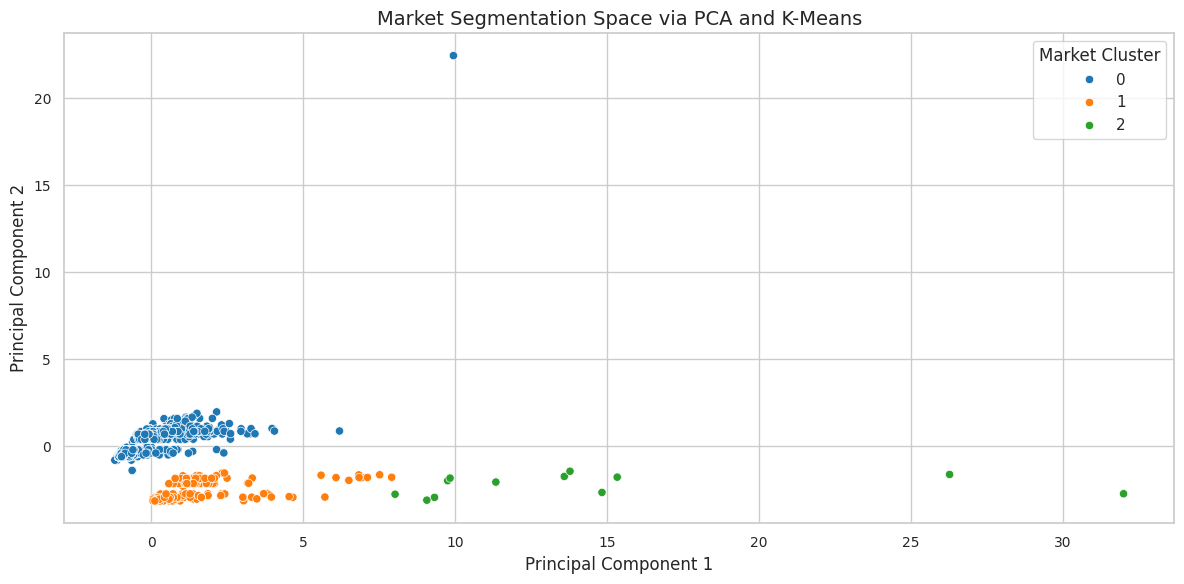

Mean Attribute Centroids Across Extracted Market Clusters:
                capacity_gb  bus_speed_mhz        price  is_bulk_server
market_cluster                                                         
0                 22.205706    4322.388138   231.882335             0.0
1                 35.031390    3664.762332   435.450045             1.0
2                416.666667    4344.333333  5077.442500             1.0


In [9]:
cluster_features = ['capacity_gb', 'bus_speed_mhz', 'price', 'is_bulk_server']
X_cluster = df_cleaned[cluster_features]

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned['market_cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_cleaned['market_cluster'], palette='tab10', alpha=1)
plt.title('Market Segmentation Space via PCA and K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Market Cluster')
plt.tight_layout()
plt.show()

print('Mean Attribute Centroids Across Extracted Market Clusters:')
print(df_cleaned.groupby('market_cluster')[cluster_features].mean())

## Inferences: Market Segmentation Profiles
* **Cluster 0: Standard Consumer Core**: This cluster captures standard user hardware, averaging 22.20 GB capacity, a 4,322 MHz clock rate, and an affordable valuation around 231.88 USD. This represents the high-volume base of the consumer market.
* **Cluster 1: Specialized Prosumer Infrastructure**: This segment represents enthusiast hardware with high-capacity configurations (averaging 35.03 GB). It is characterized by enterprise features (`is_bulk_server` = 1.0) but sits at lower clock speeds (3,664 MHz) with a higher average price of 435.45 USD. This points to older enterprise hardware listed on the secondary market.
* **Cluster 2: High-Density Enterprise Architecture**: This small, high-value cluster targets major data center infrastructure. It features extreme hardware density, with average capacities reaching 416.66 GB, high clock rates (4,344 MHz), and a high price point averaging 5,077.44 USD per listing.


# 6. Predictive Machine Learning Architecture (Regression modeling)
This step implements a gradient boosting model to project RAM listing prices from technical specifications and engineered attributes.


In [10]:
target_col = 'price'
drop_cols = ['price', 'wasPrice', 'title', 'seller_id', 'itemLocation', 'lastUpdated', 'mpn']
features = [c for c in df_cleaned.columns if c not in drop_cols]

X = df_cleaned[features]
y = df_cleaned[target_col]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(max_iter=150, learning_rate=0.08, random_state=42))
])

model_pipeline.fit(X_train, y_train)
y_pred_test = model_pipeline.predict(X_test)

print('Regression Engine Model Execution Performance Indicators:')
print(f'Test R2 Score: {r2_score(y_test, y_pred_test):.4f}')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}')

Regression Engine Model Execution Performance Indicators:
Test R2 Score: 0.3684
Test MAE: 104.6349


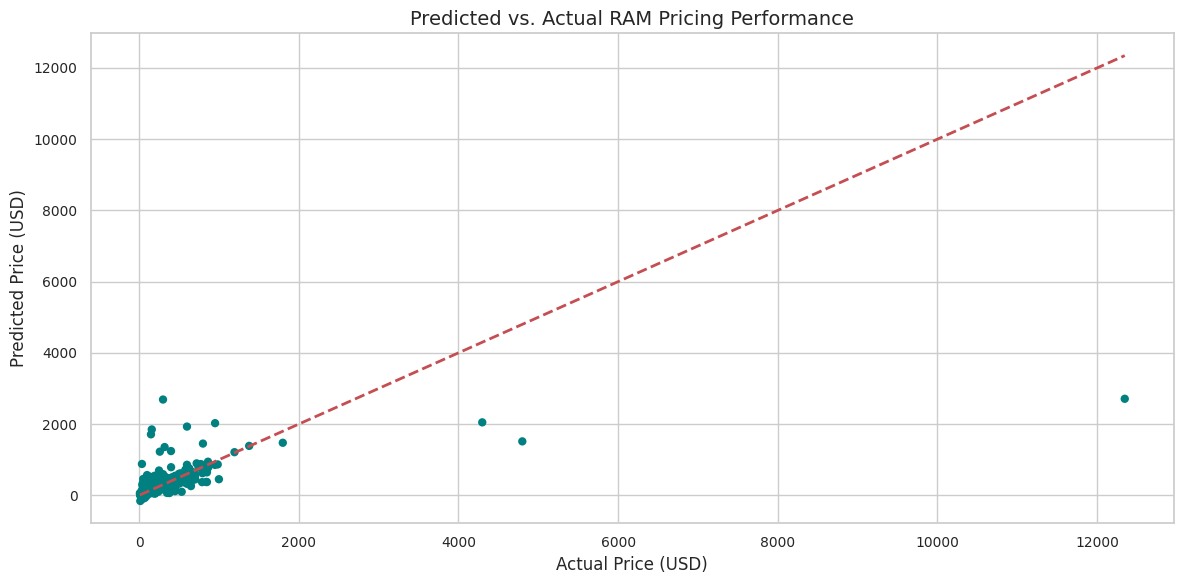

In [11]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=1, color='#008080', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicted vs. Actual RAM Pricing Performance')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.tight_layout()
plt.show()

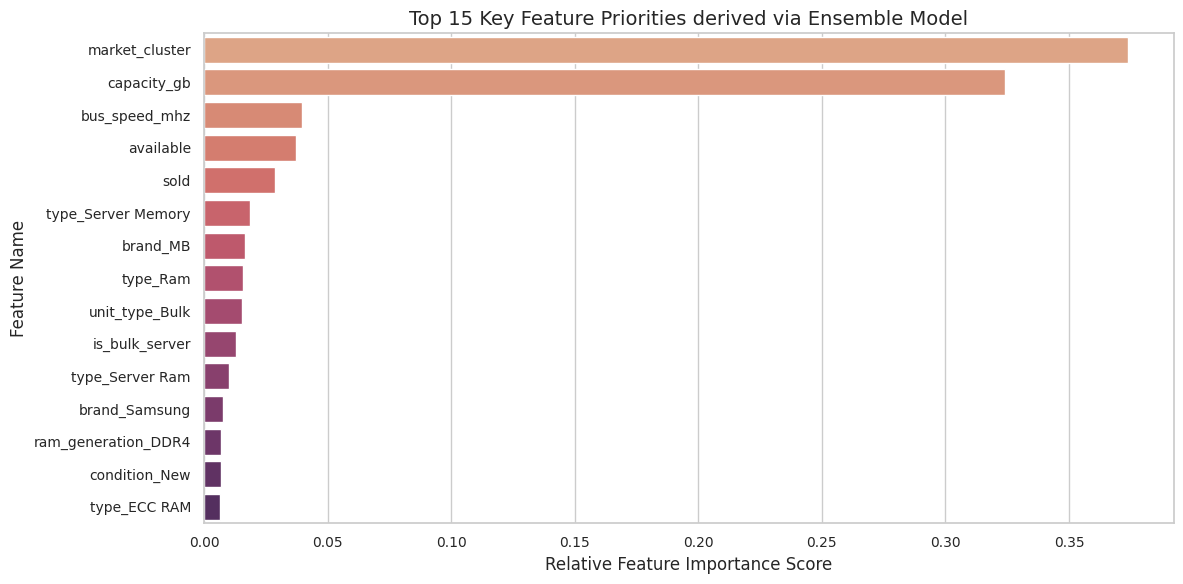

Feature prioritization layout complete.


In [12]:
rf_surrogate = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])
rf_surrogate.fit(X_train, y_train)

encoded_cat_features = rf_surrogate.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols).tolist()
all_features_transformed = numerical_cols + encoded_cat_features
importances = rf_surrogate.named_steps['regressor'].feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 15
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:top_n]], y=[all_features_transformed[i] for i in indices[:top_n]], palette='flare')
plt.title('Top 15 Key Feature Priorities derived via Ensemble Model')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()
print('Feature prioritization layout complete.')

## Inferences and Model Error Analysis
* **Variance Tracking ($R^2 = 0.3684$)**: The baseline model explains roughly 36.84 percent of price variance. This lower score is driven by extreme price variations in the enterprise space, where server clusters can stretch from double digits to over 12,000 USD for identical physical profiles.
* **Mean Absolute Error Check ($MAE = 104.63$)**: The average error of 104.63 USD reflects these large variance gaps. For consumer components under 200 USD, the prediction error remains tight. However, the model sees larger errors when forecasting high-capacity server arrays and multi-unit enterprise packages.
* **Feature Importance Hierarchy**: Feature analysis reveals that total hardware density (`capacity_gb`) serves as the primary price predictor. This is followed by underlying category states, vendor classifications, and engineered text flags like `is_ecc` and `cl_latency`, confirming that raw technical specs dominate over cosmetic branding factors.


# Model Execution Synthesis and Diagnostic Analysis
This project details a complete data pipeline for secondary computer components using the 2026 e-commerce dataset. By combining text mining, robust data clearing, and machine learning, the pipeline extracts hidden value patterns across different hardware generations. Unsupervised models separate the dataset into distinct consumer, prosumer, and enterprise clusters, while our gradient boosting regressor highlights capacity as the primary driver of market valuation. These results show that hardware pricing patterns are deeply tied to technical parameters rather than retail marketing metrics.
